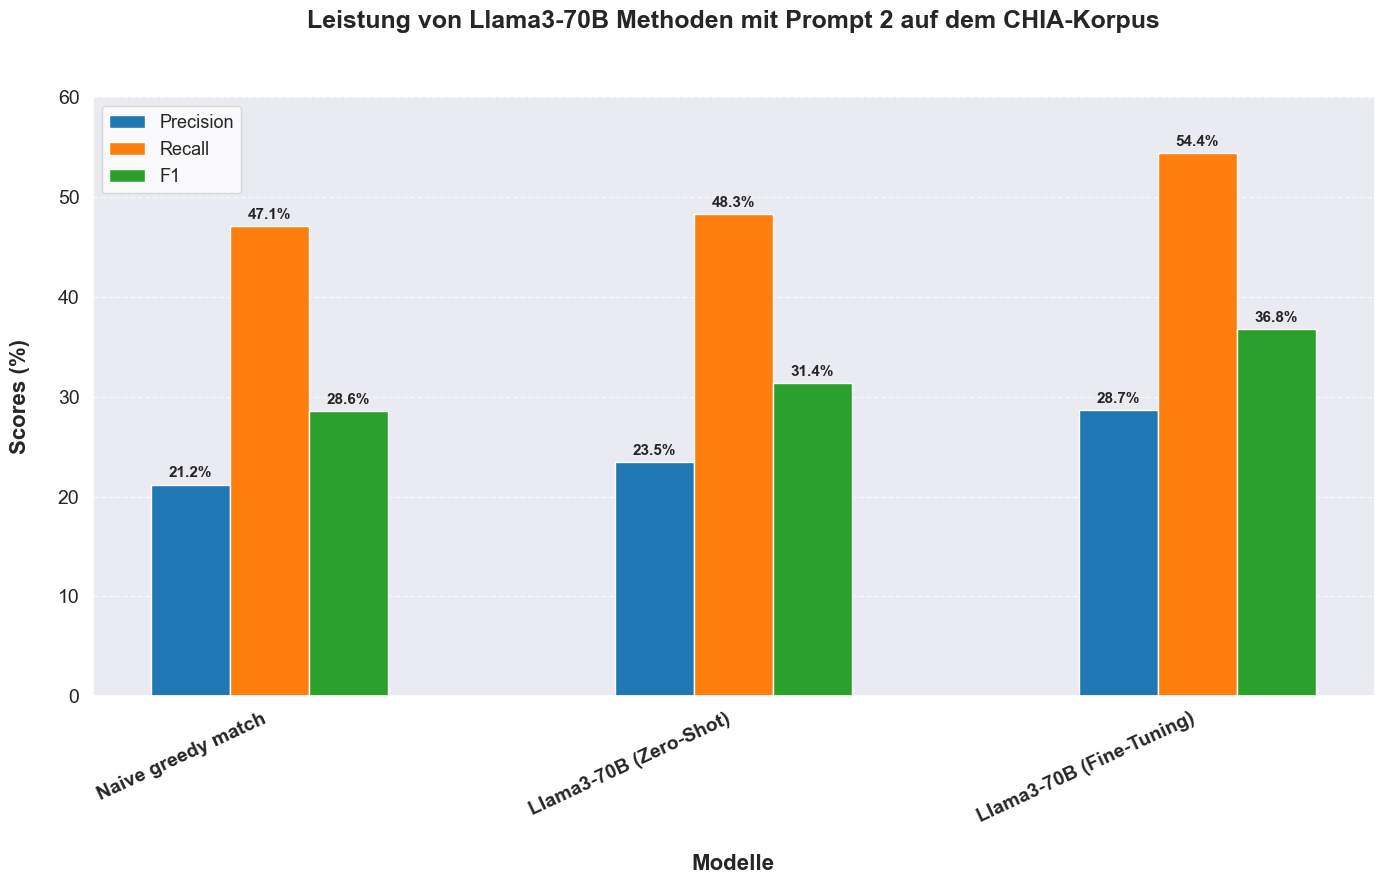

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


sns.set_theme(style="darkgrid")
data = {
    'Model': [
        'Naive greedy match',
        'Llama3-70B (Zero-Shot)',
        'Llama3-70B (Fine-Tuning)'
    ],
    'P': [21.2, 23.5, 28.7],
    'R': [47.1, 48.3, 54.4],
    'F1': [28.6, 31.4, 36.8],
    'Category': ['Baseline', 'Zero-Shot', 'Fine-Tuning']
}

df = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(14, 9))
x = np.arange(len(df))
width = 0.17  
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
rects1 = ax.bar(x - width, df['P'], width, label='Precision', color=colors[0])
rects2 = ax.bar(x, df['R'], width, label='Recall', color=colors[1])
rects3 = ax.bar(x + width, df['F1'], width, label='F1', color=colors[2])
def autolabel(rects, values):
    for rect, value in zip(rects, values):
        height = rect.get_height()
        if not np.isnan(height):
            ax.annotate(f'{value:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  
                        textcoords="offset points",
                        ha='center', va='bottom', rotation=0, fontsize=11, fontweight='bold')  # Make percentage bold

autolabel(rects1, df['P'])
autolabel(rects2, df['R'])
autolabel(rects3, df['F1'])
ax.set_xlabel('Modelle', fontsize=16, fontweight='bold', labelpad=20)
ax.set_ylabel('Scores (%)', fontsize=16, fontweight='bold', labelpad=20)
ax.set_title('Leistung von Llama3-70B Methoden mit Prompt 2 auf dem CHIA-Korpus',
             fontsize=18, fontweight='bold', pad=50)
ax.set_xticks(x)
ax.set_xticklabels(df['Model'], rotation=25, ha='right', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(60, ax.get_ylim()[1]))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)
ax.tick_params(axis='y', which='both', labelsize=14)
legend = ax.legend(loc='upper left', ncol=1, fontsize=13, frameon=True)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('lightgray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chia.svg', format='svg', bbox_inches='tight')
plt.show()